#**Laboratorio: Introducción Optimización**

La teoría de optimización es la base sobre la cual se construyen
la mayor parte de las técnicas de machine learning. Durante esta práctica de laboratorio veremos la introducción al paquete optimize de scipy y un ejemplo haciendo uso de este.


#**1. Paquete optimize de scipy**

El paquete optimize de scipy posee distintas herramientas que permiten minimizar funciones. Una de las funciones más útiles del paquete optimize es *minimize*, que permite minimizar funciones escalares no lineales de una o más variables. A continuación se describen los argumentos de la función para su funcionamiento y se da un ejemplo de cálculo de minimizadores usando *minimize*.

En primer lugar, se importa la función minimize del paquete optimize de scipy

In [ ]:
from scipy.optimize import minimize

La función minimize recibe como argumentos lo siguiente:

**Argumentos obligatorios:**

- fun: la función que se desea minimizar. Por ejemplo, si se desea minimizar una función de 3 variables, la función no debe recibir 3 argumentos, sino un solo argumento X que es un array de 3 posiciones, donde cada posición corresponde a cada una de las variables. Es decir:

  Forma incorrecta:

  ```
  def funcion (x,y,z):
    return x + y + z
  ```
  Forma correcta:

  ```
  def funcion(X):
    x,y,z = X
    return x + y + z
  ```

- X0: un array de n elementos donde n es el número de variables de la función y que corresponde a las condiciones iniciales de cada variable.

**Argumentos opcionales:**

- args: Una tupla de elementos donde cada elemento corresponde a los parámetros adicionales de la función. Por ejemplo, si se tiene una función que recibe 3 variables y un parámetro p, la definición correcta de la función debería ser:

  ```
  def funcion(X, p):
    x,y,z = X
    return x*p + y + z
  ```

  Y en este caso, al invocar la función *minimize* se debería incluir el argumento *args* como una tupla de 1 posición, donde el valor corresponde al valor del parámetro p. Asumiendo que p tiene un valor de 0.2, se debería cumplir lo siguiente:

  ```
  argumentos = (0.2,)
  resultado = minimize(funcion, args = argumentos)
  ```

- bounds: Los límites de cada uno de los parámetros representados como una lista de tuplas, donde la lista tiene longitud *n* siendo n el número de variables de la función y cada tupla debe tener dos elementos de la siguiente manera: *(min, max)* y que corresponden al mínimo y máximo de cada variable. Si se coloca *None* en alguno de los parámetros min o max se asume que el parámetro no tiene límite inferior o superior dependiendo del caso. Por ejemplo:

  Se tiene una función *f* de 3 variables, donde la primera variable debe estar en el rango (10,20), la segunda variable debe ser mayor a 0 y la tercera variable debe ser menor a 10.

  En este caso, el código correcto para definir los límites de las variables es el siguiente:

  ```
  limites = [(10,20),(0,None),(None,10)]
  resultado = minimize(funcion, bounds = limites)
  ```

- constraints: Las restricciones que se tienen sobre las variables en forma de lista de diccionarios, donde cada elemento corresponde a cada una de las restricciones. Esta restricción debería estar escrita de la forma $g(x)\ge 0$. Por ejemplo, asuma que se tiene un problema de optimización con una función de 3 variables y la siguiente restricción:
  \begin{align}
  4 x_1 + 3 x_2 - x_3 >= 4
  \end{align}
  Esta restrición entonces la reescribimos de la siguiente forma:
  \begin{align}
  4 x_1 + 3 x_2 - x_3 -4 >= 0 .
  \end{align}
  La restricción se debe definir como una función aplicable sobre las variables y que siempre debe retornar el resultado de la función igualada a 0. En este caso, la función de restricción debería ser:

  ```
  def restriccion_1(X):
      x_1, x_2, x_3 = X
      return 4*x_1 + 3*x_2 - x_3 - 4
  ```

  Note que en la función se resta 4 a la condición original para garantizar que la restricción esté igualada a 0.

  Una vez definida la función de restricción, se debe armar un diccionario con al menos 2 llaves: *type*, que puede tener valores "eq" o "ineq" y define si la restricción es una igualdad ($x_1 + x_2 = 0$) o una desigualdad ($x_1 + x_2 <= 0$); en caso de que la restricción sea una desigualdad, esta siempre debe ser expresada en la forma menor o igual a "<=".

  Como segunda llave se tiene *fun*, y su valor es la función que define la restricción. En el caso de la función *restriccion_1*, definida anteriormente, el diccionario que se debe armar para poder incluirla debe ser el siguiente:

  ```
  rest1 = {"type":"ineq","fun":restriccion_1}
  ```
  Por último, cada una de las restricciones (diccionarios) debe ser colocada en una lista e ingresada como parámetro *constrains*.








**Retorno:**

La función minimize retorna un diccionario con llaves *success* (booleano que indica si la solución pudo se hallada o no), *message* (mensaje que describe la causa de terminación de la ejecución del algoritmo) y *x* (array que contiene la solución).

#**Ejemplo de uso de la función**

Asuma que se quiere minimizar la función $f(x) = 3(x_1 - 10)^2 + 4(x_2 - 5)^2$ sujeto a la restricción $x_1^2+x_2^2 \leq 9$ con $x_1 \geq 1$ y $x_2 \geq 2$.

In [ ]:
#En primer lugar, importamos las funciones necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [ ]:
#Ahora, definimos la función de costo a minimizar
def f_costo(X):
  return 3*(X[0] - 10)**2 + 4*(X[1] - 5)**2

In [ ]:
#Definimos las restricciones y límites en el formato necesario para minimize
def f_restriccion(X):
  return 9 - X[0]**2  - X[1]**2

constraints = [{"type":"ineq","fun":f_restriccion},]
boundaries = [(1, None),(2, None)]

#Definimos las condiciones iniciales que queremos aplicar

x0 = [5,5]

In [ ]:
#Calculamos el resultado con la función minimize
res = minimize(f_costo,x0, bounds=boundaries, constraints=constraints)

In [ ]:
print(res)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 216.83592130158132
       x: [ 2.236e+00  2.000e+00]
     nit: 7
     jac: [-4.658e+01 -2.400e+01]
    nfev: 22
    njev: 7


In [ ]:
#Extraemos el resultado (parámetro x de la solución)
minimizador = res["x"]
print(f"El minimizador encontrado es: {minimizador}")

El minimizador encontrado es: [2.23606798 2.        ]


Como resultado de esta minimización obtenemos el mínimo de la función de costo en el atributo *fun*. Por otra parte, el minimizador se encuentra en el atributo x, este hace referencia a los valores que deben tomar $x_1$ y $x_2$ para que cumpla el valor de la minimización con las restricciones establecidas.

#**Ejercicios**

**1. Cambie la restricción $x_1^2+x_2^2 \leq 9$ del ejemplo anterior por $2x_1^4+x_2^2 \leq 400$. Identifique cómo cambian los resultados de la minimización para la función $f(x)$.**

In [ ]:
def f_restriccion_1(X):
  return 400 - 2*X[0]**2  - X[1]**2

constraints = [{"type":"ineq","fun":f_restriccion_1},]
boundaries = [(1, None),(2, None)]

res_1 = minimize(f_costo,x0, bounds=boundaries, constraints=constraints)
print(res_1)

minimizador_1 = res_1["x"]
print(f"El minimizador encontrado es: {minimizador_1}")


 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 3.8640948671146923e-16
       x: [ 1.000e+01  5.000e+00]
     nit: 5
     jac: [-1.329e-09  1.663e-09]
    nfev: 17
    njev: 5
El minimizador encontrado es: [9.99999999 4.99999999]


**2. Minimice la función $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$ sujeto a la restricción $2x_1+x_2\leq 6$ con $x_1,x_2 \geq 0$.**

In [ ]:
#Se define la función de costo a minimizar
def f_costo_2(X):
  return (X[0] - 3)**2 + (X[1] - 2)**2

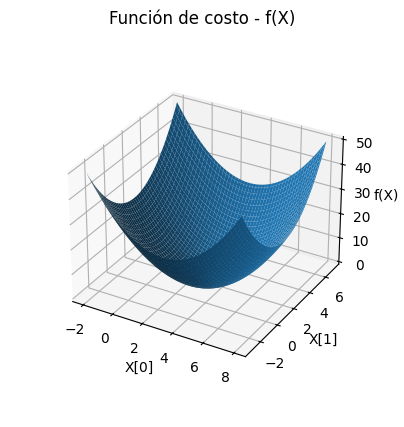

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"} ,  figsize = (5, 5))
x_1 = np.linspace(-2,8,100)
x_2 = np.linspace(-3,7,100)
(X_1, X_2) = np.meshgrid(x_1, x_2)
f = (X_1 - 3)**2 + (X_2 - 2)**2
surf = ax.plot_surface(X_1, X_2, f)
ax.set_xlabel("X[0]")
ax.set_ylabel("X[1]")
ax.set_zlabel("f(X)")
ax.set_box_aspect(aspect=None, zoom=0.8)
ax.set(title = 'Función de costo - f(X)')

plt.show()

In [ ]:
#Definimos las restricciones y límites en el formato necesario para minimize
def f_restriccion_2(X):
  return 6 - 2*X[0]  - X[1]

constraints_2 = [{"type":"ineq","fun":f_restriccion_2},]
boundaries_2 = [(0, None),(0, None)]

#Definimos las condiciones iniciales que queremos aplicar

x0 = [5,5]

In [ ]:
#Calculamos el resultado con la función minimize
res_2 = minimize(f_costo_2,x0, bounds=boundaries_2, constraints=constraints_2)

In [ ]:
print(res_2)

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 0.7999999999999992
       x: [ 2.200e+00  1.600e+00]
     nit: 5
     jac: [-1.600e+00 -8.000e-01]
    nfev: 15
    njev: 5


In [ ]:
#Extraemos el resultado (parámetro x de la solución)
minimizador = res_2["x"]
print(f"El minimizador encontrado es: {minimizador}")

El minimizador encontrado es: [2.2 1.6]
